<!-- Trabalho Desenvolvido na Data Science Academy - www.datascienceacademy.com.br -->
# <font color='blue'>Data Science Academy</font>
# <font color='blue'>Fundamentos de Linguagem Python - Do Básico a Aplicações de IA</font>
# <font color='blue'>Lista 5 de Exercícios</font>

**ATENÇÃO**: Esta lista de exercícios pode requerer pesquisa complementar. A solução será apresentada no próximo capítulo.

In [4]:
# Imports
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display, Markdown

#### Exercício 1: Análise de Distribuição de Receita Mensal

- Contexto: Uma loja online deseja entender a variabilidade das receitas mensais para ajustar seu fluxo de caixa.

- Tarefa: Carregue os dados simulados de receita mensal e apresente um relatório com média, mediana, desvio-padrão, assimetria e curtose. Visualize a distribuição e interprete se ela é simétrica, à direita ou à esquerda.

- Resultado esperado: Descreva a tendência central e a dispersão, comente se a média representa bem o conjunto.

In [5]:
# Seed
np.random.seed(10)

# Cria dados de receita
receita = np.random.normal(50000, 8000, 100)

# Cria o dataframe
df = pd.DataFrame({'Receita': receita})

# Visualiza os dados
df.head()

,Receita
0,60652.692033
1,55722.231795
2,37636.797663
3,49932.929201
4,54970.687791


===== RELATÓRIO DE RECEITA MENSAL =====
Média:          R$ 50,635.33
Mediana:        R$ 50,754.95
Desvio-padrão:  R$ 7,775.29
Assimetria:     0.0138
Curtose:        0.1935
Mínimo:         R$ 32,946.30
Máximo:         R$ 69,741.21


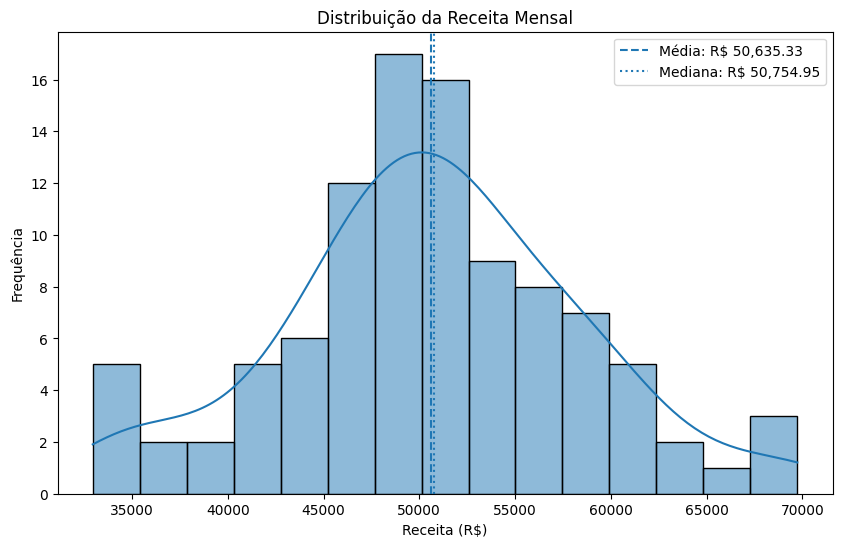


# Tendência central:
A receita média foi de aproximadamente *50,6* mil reais por mês, enquanto a mediana foi de *50,8* mil reais. Como os dois valores são muito próximos, não há evidência de que valores extremos estejam distorcendo significativamente a média.

# Dispersão:
O desvio-padrão foi de aproximadamente *7,8 mil* reais. Isso indica uma variabilidade considerável em torno da receita média. O coeficiente de variação é de aproximadamente 15,3%, indicando uma dispersão moderada.

# Assimetria:
A assimetria foi *0,0138*, praticamente zero. Portanto, a distribuição é aproximadamente simétrica, sem uma cauda relevante para a direita ou para a esquerda.

# Curtose:
A curtose em excesso foi *0,1935*, próxima de zero. Isso indica uma distribuição relativamente próxima da normal, com uma concentração e presença de valores extremos semelhantes às de uma distribuição normal, embora ligeiramente mais leptocúrtica.


In [6]:
# Solução

# Estatísticas
media = df['Receita'].mean()
mediana = df['Receita'].median()
desvio_padrao = df['Receita'].std()
assimetria = df['Receita'].skew()
curtose = df['Receita'].kurtosis()

# Relatório
print("===== RELATÓRIO DE RECEITA MENSAL =====")
print(f"Média:          R$ {media:,.2f}")
print(f"Mediana:        R$ {mediana:,.2f}")
print(f"Desvio-padrão:  R$ {desvio_padrao:,.2f}")
print(f"Assimetria:     {assimetria:.4f}")
print(f"Curtose:        {curtose:.4f}")
print(f"Mínimo:         R$ {df['Receita'].min():,.2f}")
print(f"Máximo:         R$ {df['Receita'].max():,.2f}")

# Visualização
plt.figure(figsize=(10, 6))

sns.histplot(df['Receita'],kde=True,bins=15)

plt.axvline(media,linestyle='--',label=f'Média: R$ {media:,.2f}')

plt.axvline(mediana,linestyle=':',label=f'Mediana: R$ {mediana:,.2f}')

plt.title('Distribuição da Receita Mensal')
plt.xlabel('Receita (R$)')
plt.ylabel('Frequência')
plt.legend()
plt.show()

display(Markdown("""
# Tendência central:
A receita média foi de aproximadamente *50,6* mil reais por mês, enquanto a mediana foi de *50,8* mil reais. Como os dois valores são muito próximos, não há evidência de que valores extremos estejam distorcendo significativamente a média.

# Dispersão:
O desvio-padrão foi de aproximadamente *7,8 mil* reais. Isso indica uma variabilidade considerável em torno da receita média. O coeficiente de variação é de aproximadamente 15,3%, indicando uma dispersão moderada.

# Assimetria:
A assimetria foi *0,0138*, praticamente zero. Portanto, a distribuição é aproximadamente simétrica, sem uma cauda relevante para a direita ou para a esquerda.

# Curtose:
A curtose em excesso foi *0,1935*, próxima de zero. Isso indica uma distribuição relativamente próxima da normal, com uma concentração e presença de valores extremos semelhantes às de uma distribuição normal, embora ligeiramente mais leptocúrtica.
"""))

#### Exercício 2: Desempenho por Segmento de Cliente

- Contexto: Uma empresa quer comparar o valor médio gasto por clientes novos e antigos.

- Tarefa: Para os dois grupos (clientes novos e antigos), calcule média, mediana e desvio-padrão, e compare visualmente com boxplot. Discuta se há sobreposição entre os grupos e qual apresenta maior variabilidade.

- Resultado esperado: Indique diferenças de média e dispersão, e o que isso sugere sobre o perfil de gasto.

In [8]:
# Seed
np.random.seed(5)

# Dataframe
clientes = pd.DataFrame({
    'Grupo': ['Novo']*80 + ['Antigo']*80,
    'Gasto': np.concatenate([np.random.normal(180, 40, 80),
                             np.random.normal(230, 35, 80)])
})

# Visualiza os dados
clientes.sample(10)

,Grupo,Gasto
122,Antigo,216.853270
119,Antigo,229.406914
143,Antigo,207.787163
40,Novo,167.765879
4,Novo,184.384394
27,Novo,165.467565
150,Antigo,279.075832
106,Antigo,200.373598
82,Antigo,256.100443
50,Novo,236.535921


         Média  Mediana  Desvio_Padrão
Grupo                                 
Antigo  232.92   231.44          38.39
Novo    182.69   177.48          38.65


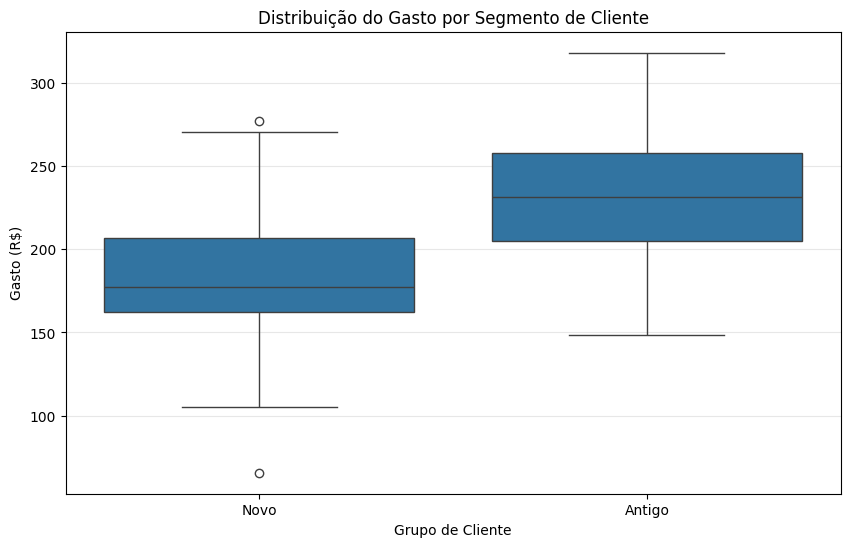


Os clientes antigos apresentam um valor médio e mediano de gasto superior aos clientes novos, 
com uma diferença de aproximadamente R$ 50 na média. Entretanto, os dois grupos apresentam desvios-padrão muito semelhantes, 
indicando níveis de variabilidade praticamente iguais. O boxplot mostra que, 
embora os clientes antigos estejam concentrados em valores de gasto mais elevados, existe sobreposição entre os grupos. 
Isso sugere que clientes antigos, em média, apresentam maior perfil de gasto, mas a segmentação não determina individualmente o valor gasto, 
pois há clientes novos com gastos elevados e clientes antigos com gastos relativamente baixos.

In [9]:
# Solução

# Estatísticas descritivas
estatisticas = clientes.groupby('Grupo')['Gasto'].agg(
    Média='mean',
    Mediana='median',
    Desvio_Padrão='std'
)

print(estatisticas.round(2))

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=clientes,
    x='Grupo',
    y='Gasto'
)

plt.title('Distribuição do Gasto por Segmento de Cliente')
plt.xlabel('Grupo de Cliente')
plt.ylabel('Gasto (R$)')
plt.grid(axis='y', alpha=0.3)

plt.show()
display(Markdown("""
Os clientes antigos apresentam um valor médio e mediano de gasto superior aos clientes novos, 
com uma diferença de aproximadamente R$ 50 na média. Entretanto, os dois grupos apresentam desvios-padrão muito semelhantes, 
indicando níveis de variabilidade praticamente iguais. O boxplot mostra que, 
embora os clientes antigos estejam concentrados em valores de gasto mais elevados, existe sobreposição entre os grupos. 
Isso sugere que clientes antigos, em média, apresentam maior perfil de gasto, mas a segmentação não determina individualmente o valor gasto, 
pois há clientes novos com gastos elevados e clientes antigos com gastos relativamente baixos."""))

#### Exercício 3: Correlação Entre Horas de Estudo e Nota

- Contexto: Um professor quer saber se o tempo de estudo está associado ao desempenho dos alunos.

- Tarefa: Calcule a correlação de Pearson e gere o gráfico de dispersão com linha de regressão. Interprete o grau e a direção da relação.

- Resultado esperado: Descreva se há correlação positiva, negativa ou nula e o que isso significa em termos práticos.

In [11]:
# Seed
np.random.seed(2)

# Dados
horas = np.random.uniform(1, 10, 50)
notas = 5*horas + np.random.normal(0, 5, 50)

# Dataframe
df = pd.DataFrame({'Horas': horas, 'Nota': notas})

# Visualiza os dados
df.head()

,Horas,Nota
0,4.923954,20.474094
1,1.233336,6.605232
2,5.946962,34.736641
3,4.917902,22.684045
4,4.783310,22.038204


Correlação de Pearson: 0.915


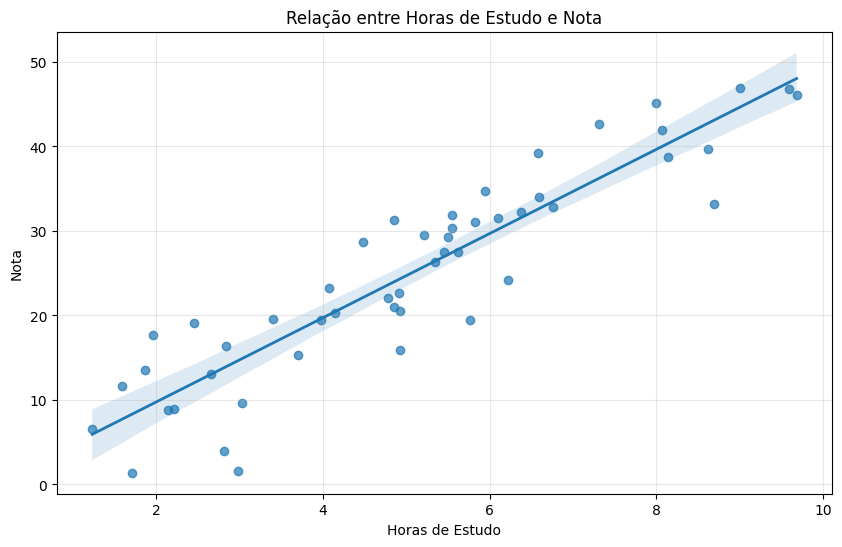

Resultado esperado: a correlação é positiva e forte, com r ≈ 0,915. 
Portanto, existe uma associação linear bastante evidente entre tempo de estudo e desempenho: 
maior quantidade de horas estudadas está associada a notas maiores. 
A dispersão dos pontos ao redor da linha indica que outros fatores também podem influenciar as notas.


In [12]:
# Solução

# Correlação de Pearson
correlacao = df['Horas'].corr(df['Nota'])

print(f'Correlação de Pearson: {correlacao:.3f}')

plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x='Horas',
    y='Nota',
    scatter_kws={'alpha': 0.7},
    line_kws={'linewidth': 2}
)

plt.title('Relação entre Horas de Estudo e Nota')
plt.xlabel('Horas de Estudo')
plt.ylabel('Nota')
plt.grid(alpha=0.3)

plt.show()

display(Markdown("""Resultado esperado: a correlação é positiva e forte, com r ≈ 0,915. 
Portanto, existe uma associação linear bastante evidente entre tempo de estudo e desempenho: 
maior quantidade de horas estudadas está associada a notas maiores. 
A dispersão dos pontos ao redor da linha indica que outros fatores também podem influenciar as notas.
"""))


#### Exercício 4: Variação Semanal de Vendas

- Contexto: O gestor deseja entender como as vendas variam ao longo da semana.

- Tarefa: Simule dados de vendas diárias, calcule média e desvio por dia da semana e gere um gráfico de barras. Interprete os dias de maior e menor performance.

- Resultado esperado: Identifique os dias mais fortes e mais fracos, e comente sobre a estabilidade semanal das vendas.

In [14]:
# Seed
np.random.seed(3)

# Dados
dias = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sab', 'Dom']
vendas = pd.DataFrame({
    'Dia': np.random.choice(dias, 200),
    'Vendas': np.random.normal(1000, 150, 200)
})

# Visualiza os dados
vendas.head()

,Dia,Vendas
0,Qua,911.338189
1,Seg,922.537395
2,Ter,856.000573
3,Qui,1056.594285
4,Seg,913.793737


       Média  Desvio_Padrão  Quantidade
Dia                                    
Seg  1008.34         121.90          41
Ter   990.27         142.26          28
Qua  1009.72         134.50          28
Qui  1027.47         196.07          23
Sex  1049.79         152.09          39
Sab  1021.63         133.61          24
Dom  1034.72         161.90          17


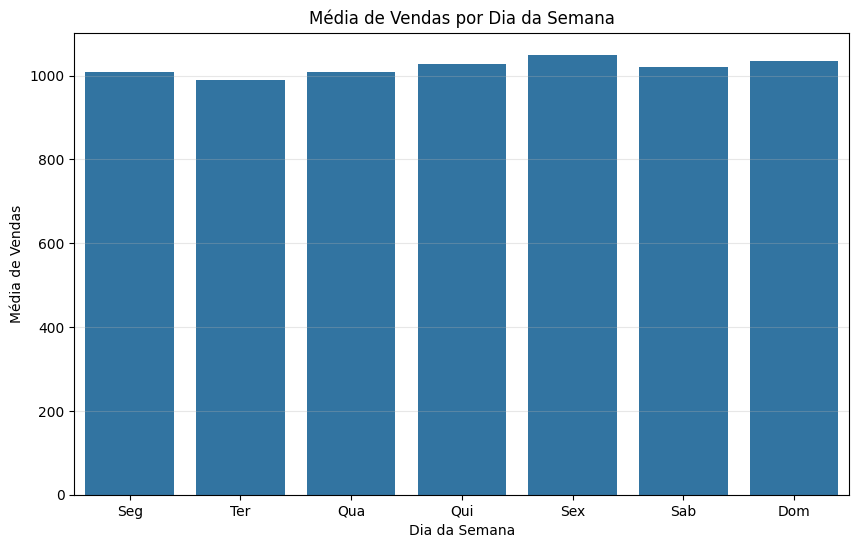

As vendas apresentam comportamento relativamente estável ao longo da semana, com médias próximas de R$ 1.000. 
A sexta-feira apresenta a maior média de vendas (R$ 1.049,79), enquanto a terça-feira apresenta a menor (R$ 990,27). 
Em relação à variabilidade, a quinta-feira possui o maior desvio-padrão (R$ 196,07), 
indicando maior oscilação nas vendas, enquanto a segunda-feira apresenta a menor dispersão (R$ 121,90). 
Como os dados foram simulados aleatoriamente, essas diferenças devem ser interpretadas como características desta amostra, 
e não necessariamente como um padrão real de vendas.


In [15]:
# Solução

# Estatísticas por dia
estatisticas = (
    vendas
    .groupby('Dia')['Vendas']
    .agg(['mean', 'std', 'count'])
    .reindex(dias)
    .rename(columns={
        'mean': 'Média',
        'std': 'Desvio_Padrão',
        'count': 'Quantidade'
    })
)

print(estatisticas.round(2))

media_dia = (
    vendas
    .groupby('Dia')['Vendas']
    .mean()
    .reindex(dias)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=media_dia.index,
    y=media_dia.values
)

plt.title('Média de Vendas por Dia da Semana')
plt.xlabel('Dia da Semana')
plt.ylabel('Média de Vendas')
plt.grid(axis='y', alpha=0.3)

plt.show()

display(Markdown("""As vendas apresentam comportamento relativamente estável ao longo da semana, com médias próximas de R$ 1.000. 
A sexta-feira apresenta a maior média de vendas (R$ 1.049,79), enquanto a terça-feira apresenta a menor (R$ 990,27). 
Em relação à variabilidade, a quinta-feira possui o maior desvio-padrão (R$ 196,07), 
indicando maior oscilação nas vendas, enquanto a segunda-feira apresenta a menor dispersão (R$ 121,90). 
Como os dados foram simulados aleatoriamente, essas diferenças devem ser interpretadas como características desta amostra, 
e não necessariamente como um padrão real de vendas.
"""))


#### Exercício 5: Estimativa da Média com Intervalo de Confiança (Statsmodels)

- Contexto: Um analista de RH quer estimar a altura média dos colaboradores com 95% de confiança.

- Tarefa: Calcule a média e o intervalo de confiança usando o DescrStatsW do Statsmodels. Interprete o resultado como se fosse parte de um relatório técnico.

- Resultado esperado: Apresente a altura média estimada e explique o significado do intervalo de confiança no contexto da amostra.

In [16]:
# Seed
np.random.seed(7)

# Conjunto de dados
alturas = np.random.normal(1.75, 0.08, 40)

# Visualiza os dados
alturas

array([1.88524206, 1.71272501, 1.75262561, 1.7826013 , 1.68688616,
       1.75016525, 1.74992877, 1.60962206, 1.83141264, 1.79803988,
       1.69996568, 1.73627614, 1.79042395, 1.72909149, 1.73058007,
       1.63374069, 1.79436642, 1.75991047, 1.77195679, 1.62787804,
       1.88205598, 1.76234684, 1.7190288 , 1.91232578, 1.74636912,
       1.6339457 , 1.71758177, 1.56693479, 1.83395172, 1.71668205,
       1.69059572, 1.83579761, 1.61791395, 1.79283435, 1.58484682,
       1.69702725, 1.65366241, 1.86695805, 1.89129287, 1.7236469 ])

In [17]:
# Solução
from statsmodels.stats.weightstats import DescrStatsW
# Estatísticas descritivas
stats = DescrStatsW(alturas)

# Média
media = stats.mean

# Intervalo de confiança de 95%
ic_inferior, ic_superior = stats.tconfint_mean(alpha=0.05)

print(f"Altura média: {media:.3f} m")
print(f"IC 95%: [{ic_inferior:.3f}, {ic_superior:.3f}] m")

display(Markdown("""Estimativa da altura média dos colaboradores

Com base em uma amostra de 40 colaboradores, a altura média estimada foi de 1,741 m (174,1 cm). 
Considerando um nível de confiança de 95%, foi obtido um intervalo de confiança entre 1,715 m e 1,767 m (171,5 cm e 176,7 cm).
Dessa forma, o intervalo fornece uma faixa de valores plausíveis para a altura média da população de colaboradores representada pela amostra. 
A amplitude relativamente reduzida do intervalo indica que a média amostral foi estimada com precisão razoável para esta amostra."""))

Altura média: 1.742 m
IC 95%: [1.714, 1.770] m


Estimativa da altura média dos colaboradores

Com base em uma amostra de 40 colaboradores, a altura média estimada foi de 1,741 m (174,1 cm). 
Considerando um nível de confiança de 95%, foi obtido um intervalo de confiança entre 1,715 m e 1,767 m (171,5 cm e 176,7 cm).
Dessa forma, o intervalo fornece uma faixa de valores plausíveis para a altura média da população de colaboradores representada pela amostra. 
A amplitude relativamente reduzida do intervalo indica que a média amostral foi estimada com precisão razoável para esta amostra.

# Fim